# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 51s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

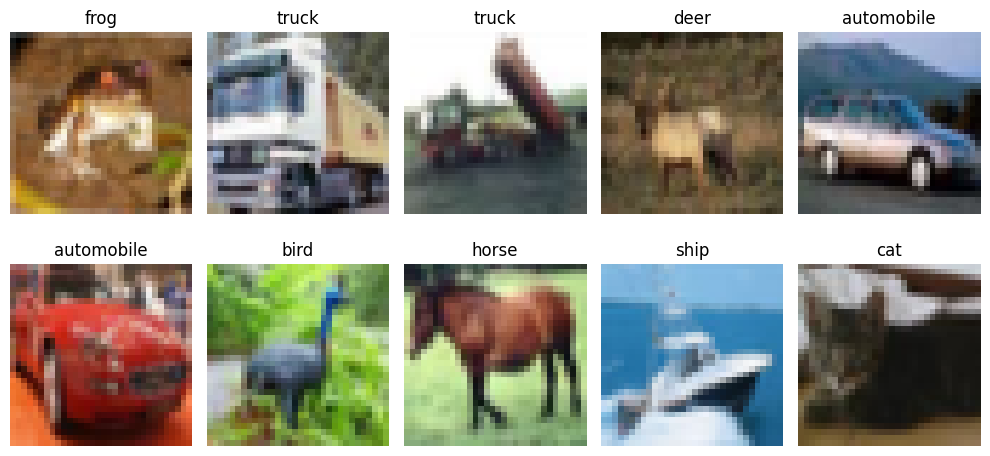

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.2666 - loss: 2.0048 - val_accuracy: 0.3366 - val_loss: 1.8356
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3201 - loss: 1.8688 - val_accuracy: 0.3650 - val_loss: 1.8032
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3367 - loss: 1.8238 - val_accuracy: 0.3576 - val_loss: 1.7814
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3514 - loss: 1.7780 - val_accuracy: 0.4096 - val_loss: 1.6952
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3661 - loss: 1.7513 - val_accuracy: 0.4008 - val_loss: 1.7019
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3717 - loss: 1.7328 - val_accuracy: 0.4140 - val_loss: 1.6718
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3826 - loss: 1.7062 - val_accuracy: 0.4106 - val_loss: 1.6731
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3806 - loss: 1.7104 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4239 - loss: 1.6387
ANN Test Accuracy: 0.4239000082015991


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.4616 - loss: 1.5094 - val_accuracy: 0.5130 - val_loss: 1.3498
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6064 - loss: 1.1294 - val_accuracy: 0.6332 - val_loss: 1.0691
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6687 - loss: 0.9539 - val_accuracy: 0.6930 - val_loss: 0.8752
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7080 - loss: 0.8410 - val_accuracy: 0.6504 - val_loss: 1.0080
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7423 - loss: 0.7406 - val_accuracy: 0.7174 - val_loss: 0.8325
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7642 - loss: 0.6707 - val_accuracy: 0.6828 - val_loss: 0.9468
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7864 - loss: 0.6049 - val_accuracy: 0.7102 - val_loss: 0.9407
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8037 - loss: 0.5496 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7225 - loss: 0.9267
CNN Test Accuracy: 0.7225000262260437


## 📈 Compare Learning Curves

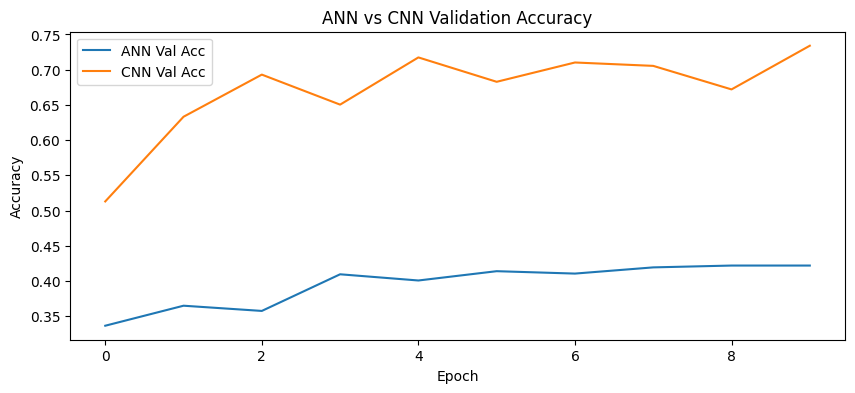

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4239
1,CNN,0.7225


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✨ Incresed ANN layers

In [ ]:
improved_ann = tf.keras.Sequential([
    tf.keras.layers.Dense(1024, activation='relu', input_shape=(3072,)),
    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(256, activation='relu'),

    tf.keras.layers.Dense(10, activation='softmax')
])

improved_ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_ann_history = improved_ann.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.2360 - loss: 2.0631 - val_accuracy: 0.2872 - val_loss: 1.9060
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2901 - loss: 1.9244 - val_accuracy: 0.3372 - val_loss: 1.8687
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3031 - loss: 1.8924 - val_accuracy: 0.3520 - val_loss: 1.8454
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3147 - loss: 1.8639 - val_accuracy: 0.3575 - val_loss: 1.8306
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3176 - loss: 1.8515 - val_accuracy: 0.3592 - val_loss: 1.8283
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3271 - loss: 1.8318 - val_accuracy: 0.3553 - val_loss: 1.8223
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3301 - loss: 1.8278 - val_accuracy: 0.3657 - val_loss: 1.8051
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3354 - loss: 1.8160 - val_accuracy: 0.

# ✨ Improved CNN

In [ ]:
improved_cnn = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32, (3,3), activation='relu',
                           input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation='softmax')
])

improved_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

improved_cnn_history = improved_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4493 - loss: 1.5582 - val_accuracy: 0.3338 - val_loss: 2.3759
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5854 - loss: 1.1766 - val_accuracy: 0.5973 - val_loss: 1.1334
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6446 - loss: 1.0132 - val_accuracy: 0.6132 - val_loss: 1.0829
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6842 - loss: 0.8979 - val_accuracy: 0.6035 - val_loss: 1.1972
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7186 - loss: 0.8052 - val_accuracy: 0.6829 - val_loss: 0.9286
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7408 - loss: 0.7367 - val_accuracy: 0.7304 - val_loss: 0.7919
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7642 - loss: 0.6724 - val_accuracy: 0.6950 - val_loss: 0.9195
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7840 - loss: 0.6200 - val_accuracy: 0

# ✨ Add EarlyStopping

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# ✨ CNN with 20 epochs and Early Stopping

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

augmented_cnn = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Conv2D(32, 3, activation='relu',
                           input_shape=(32,32,3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(10, activation='softmax')
])

augmented_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

augmented_history = augmented_cnn.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.2,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.3938 - loss: 1.7089 - val_accuracy: 0.3806 - val_loss: 1.8436
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4879 - loss: 1.4274 - val_accuracy: 0.5153 - val_loss: 1.3704
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5300 - loss: 1.3195 - val_accuracy: 0.5615 - val_loss: 1.2474
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.5589 - loss: 1.2466 - val_accuracy: 0.5672 - val_loss: 1.2472
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5844 - loss: 1.1825 - val_accuracy: 0.5748 - val_loss: 1.2423
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6038 - loss: 1.1337 - val_accuracy: 0.5884 - val_loss: 1.2288
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6214 - loss: 1.0866 - val_accuracy: 0.6482 - val_loss: 1.0125
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6343 - loss: 1.0549 - val_acc

# ✨ Evaluating All Models

In [ ]:
ann_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)[1]

cnn_acc = cnn_model.evaluate(
    x_test_norm, y_test, verbose=0
)[1]

improved_ann_acc = improved_ann.evaluate(
    x_test_flat, y_test, verbose=0
)[1]

improved_cnn_acc = improved_cnn.evaluate(
    x_test_norm, y_test, verbose=0
)[1]

augmented_acc = augmented_cnn.evaluate(
    x_test_norm, y_test, verbose=0
)[1]

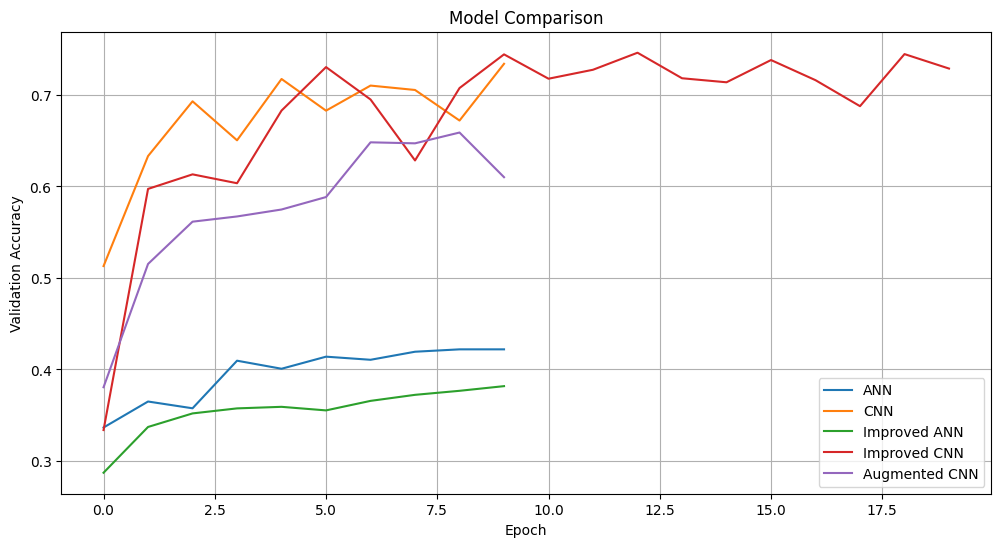

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    ann_history.history['val_accuracy'],
    label='ANN'
)

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    improved_ann_history.history['val_accuracy'],
    label='Improved ANN'
)

plt.plot(
    improved_cnn_history.history['val_accuracy'],
    label='Improved CNN'
)

plt.plot(
    augmented_history.history['val_accuracy'],
    label='Augmented CNN'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
comparison = pd.DataFrame({

    "Model": [
        "ANN",
        "CNN",
        "Improved ANN",
        "Improved CNN",
        "Augmented CNN"
    ],

    "Test Accuracy": [
        ann_acc,
        cnn_acc,
        improved_ann_acc,
        improved_cnn_acc,
        augmented_acc
    ]
})

comparison.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Test Accuracy
3,Improved CNN,0.7231
1,CNN,0.7225
4,Augmented CNN,0.6525
0,ANN,0.4239
2,Improved ANN,0.3935


# Evaluation

In [ ]:
test_loss, test_accuracy = augmented_cnn.evaluate(
    x_test_norm,
    y_test,
    verbose=1
)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6525 - loss: 1.0074
Test Accuracy: 0.6524999737739563
Test Loss: 1.007405400276184


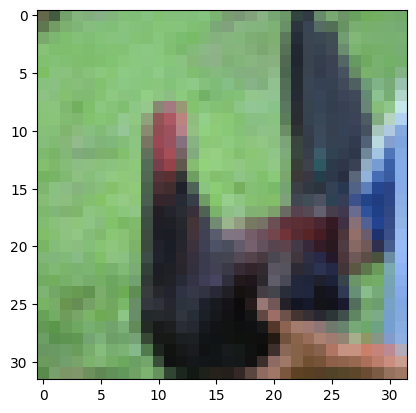

Actual Class: bird


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

index = 25

plt.imshow(x_test_norm[index])
plt.show()

print("Actual Class:",
      class_names[y_test[index][0]])

In [ ]:
prediction = augmented_cnn.predict(
    x_test_norm[index:index+1]
)

predicted_class = np.argmax(prediction)

print("Predicted Class:",
      class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
Predicted Class: bird


# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**